# WORKING WITH pandas DATA FRAMES (HETEROGENEOUS DATA)


## Personal information
Name: Tien Dat Hoang - Deakin University

LinkedIn: https://www.linkedin.com/in/tien-dat-hoang-389243172/

Email address: hdat201103@gmail.com

## Introduction
This assignment focuses on analysing public transport transaction data using Python and pandas to gain insights into tram usage patterns in Melbourne. The dataset consists of touch-on and touch-off records, along with stop location information, which are integrated to form a comprehensive trip-level dataset. Through a series of data wrangling and aggregation techniques, the analysis explores passenger activity at both stop and route levels. Key tasks include identifying the busiest stops and routes, estimating travel times, and examining hourly demand patterns. Additional analysis investigates peak-hour behaviour and differences in passenger flow throughout the day. Overall, the assignment demonstrates the application of data preprocessing, transformation, and visualisation techniques to support data-driven understanding of urban transport systems

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

scan_on = pd.read_csv("myki_2017_top20_tram_routes_ScanOnTransaction.csv")
scan_off = pd.read_csv("myki_2017_top20_tram_routes_ScanOffTransaction.csv")
stops = pd.read_csv("stop_locations.txt", sep="|")   # change sep if needed

print("Scan-on shape:", scan_on.shape)
print("Scan-off shape:", scan_off.shape)
print("Stops shape:", stops.shape)

print("\nScan-on columns:")
print(scan_on.columns.tolist())

print("\nScan-off columns:")
print(scan_off.columns.tolist())

print("\nStops columns:")
print(stops.columns.tolist())

Scan-on shape: (1904721, 9)
Scan-off shape: (611293, 9)
Stops shape: (27613, 11)

Scan-on columns:
['mode', 'business_date', 'card_id', 'card_type', 'vehicle_id', 'parent_route', 'route_id', 'stop_id', 'date_time']

Scan-off columns:
['mode', 'business_date', 'card_id', 'card_type', 'vehicle_id', 'parent_route', 'route_id', 'stop_id', 'date_time']

Stops columns:
['867', 'Weemala Court', 'Weemala Ct/Plenty River Dr (Greensborough)', 'Kerbside', 'Greensborough', '3088', 'Melbourne', 'Banyule', 'Greater Metro', '-37.689596', '145.105088']


#### Naming 'stops' columns

In [8]:
stops.columns = [
    "stop_id",
    "location_name",
    "stop_name",
    "stop_type",
    "suburb",
    "postcode",
    "city",
    "lga",
    "region",
    "latitude",
    "longitude"
]

#### Extracting stop numbers and stop names

In [10]:
# Extract stop number
stops["StopNumber"] = (
    stops["stop_name"]
    .astype(str)
    .str.extract(r"^(\d+)", expand=False)
)

# Clean stop name
stops["StopName_clean"] = (
    stops["stop_name"]
    .astype(str)
    .str.replace(r"^\d+\s*-\s*", "", regex=True)
)

print(stops[["stop_name", "StopNumber", "StopName_clean"]].head())

                                       stop_name StopNumber  \
0       Crana Gr/Plenty River Dr (Greensborough)        NaN   
1   Punkerri Cct/Plenty River Dr (Greensborough)        NaN   
2            231 Plenty River Dr (Greensborough)        231   
3   Oldstead Rd/Diamond Creek Rd (Greensborough)        NaN   
4  St Thomas PS/Diamond Creek Rd (Greensborough)        NaN   

                                  StopName_clean  
0       Crana Gr/Plenty River Dr (Greensborough)  
1   Punkerri Cct/Plenty River Dr (Greensborough)  
2            231 Plenty River Dr (Greensborough)  
3   Oldstead Rd/Diamond Creek Rd (Greensborough)  
4  St Thomas PS/Diamond Creek Rd (Greensborough)  


#### Time-Based Matching of Touch-On and Touch-Off Transactions

In [12]:
scan_on["date_time"] = pd.to_datetime(scan_on["date_time"])
scan_off["date_time"] = pd.to_datetime(scan_off["date_time"])

trips = pd.merge_asof(
    scan_on.rename(columns={
        "mode": "mode_on",
        "route_id": "route_id_on",
        "stop_id": "stop_id_on",
        "date_time": "date_time_on"
    }).sort_values("date_time_on"),

    scan_off.rename(columns={
        "mode":"mode_off",
        "route_id": "route_id_off",
        "stop_id": "stop_id_off",
        "date_time": "date_time_off"
    }).sort_values("date_time_off"),


    left_on="date_time_on",
    right_on="date_time_off",

    by=["card_id"],   # same passenger
    direction="forward",  # find next touch (touch-off)
    tolerance=pd.Timedelta("12 hours")  # trip window
)

# Clean duplicated columns created by merge
trips = trips.rename(columns={
    "mode_x": "mode",
    "business_date_x": "business_date",
    "card_type_x": "card_type",
    "vehicle_id_x": "vehicle_id",
    "parent_route_x": "parent_route"
})

trips = trips.drop(columns=[
    "business_date_y",
    "card_type_y",
    "vehicle_id_y",
    "parent_route_y"
], errors="ignore")

print(trips.shape)
print(trips.head())


(1904721, 13)
   mode_on business_date   card_id  card_type  vehicle_id  parent_route  \
0        3    2017-01-01  14660740          1        1240            16   
1        3    2017-01-01   7668390          1        1259             6   
2        3    2017-01-01  14922270          1         724            64   
3        3    2017-01-01  16075730          1         573            75   
4        3    2017-01-01  12435170          1         253            72   

   route_id_on  stop_id_on        date_time_on  mode_off  route_id_off  \
0        15575       20594 2017-01-01 03:49:04       3.0       15275.0   
1         1425       16776 2017-01-01 03:54:55       NaN           NaN   
2        16726       19499 2017-01-01 04:02:53       3.0       16726.0   
3        17514       18183 2017-01-01 04:19:42       NaN           NaN   
4        16762       19491 2017-01-01 04:42:46       NaN           NaN   

   stop_id_off       date_time_off  
0      20573.0 2017-01-01 11:39:51  
1          NaN  

#### Joining Stop Location Details to Trip Data

In [14]:
trips = trips.drop(columns=[
    "StopNameLong_on", "StopName_on", "StopNumber_on",
    "StopNameLong_off", "StopName_off", "StopNumber_off"
], errors="ignore")

stops_on = stops.rename(columns={
    "stop_id": "stop_id_on",
    "stop_name": "StopNameLong_on",
    "StopNumber": "StopNumber_on",
    "StopName_clean": "StopName_on"
})

trips = trips.merge(
    stops_on[
        ["stop_id_on", "StopNameLong_on", "StopName_on", "StopNumber_on"]
    ],
    on="stop_id_on",
    how="left"
)

stops_off = stops.rename(columns={
    "stop_id": "stop_id_off",
    "stop_name": "StopNameLong_off",
    "StopNumber": "StopNumber_off",
    "StopName_clean": "StopName_off"
})

trips = trips.merge(
    stops_off[
        ["stop_id_off", "StopNameLong_off", "StopName_off", "StopNumber_off"]
    ],
    on="stop_id_off",
    how="left"
)

print(trips.shape)
print(trips[[
    "stop_id_on", "StopNameLong_on", "StopNumber_on",
    "stop_id_off", "StopNameLong_off", "StopNumber_off"
]].head())

(1904721, 19)
   stop_id_on                                    StopNameLong_on  \
0       20594                   80-Cotham Rd/Glenferrie Rd (Kew)   
1       16776                   35-Williams Rd/High St (Prahran)   
2       19499  13-Federation Square/Swanston St (Melbourne City)   
3       18183            D2-Central Pier/Harbour Esp (Docklands)   
4       19491             3-Lincoln Square/Swanston St (Carlton)   

  StopNumber_on  stop_id_off                         StopNameLong_off  \
0            80      20573.0   76-Johnson St/Glenferrie Rd (Hawthorn)   
1            35          NaN                                      NaN   
2            13      19001.0  66-Union St/Hawthorn Rd (Brighton East)   
3           NaN          NaN                                      NaN   
4             3          NaN                                      NaN   

  StopNumber_off  
0             76  
1            NaN  
2             66  
3            NaN  
4            NaN  


#### Phase 1's Method description

This data preprocessing pipeline begins by loading three datasets: scan-on transactions, scan-off transactions, and stop location details. The stop dataset is first cleaned and standardised by renaming columns and extracting meaningful attributes, including the stop number (using regular expressions to capture leading digits) and a cleaned stop name (removing numeric prefixes). 

Next, the transaction datasets are converted to datetime format to enable temporal alignment. A key step involves linking scan-on and scan-off records using a forward merge_asof join based on card ID and timestamp, allowing each touch-on event to be matched with the nearest subsequent touch-off within a 12-hour window. This approach accounts for incomplete trips where touch-off data may be missing. After merging, redundant columns are removed, and stop-level information is integrated twice—once for touch-on and once for touch-off—using left joins on stop IDs. 

Finally, the pipeline performs validation by calculating the proportion of trips where touch-on and touch-off occur at the same stop, providing a basic sanity check on the join logic. Overall, this process effectively constructs a unified trip-level dataset enriched with spatial stop information for further analysis.

#### Phase 1's Findings discusison

The merged dataset successfully combines touch-on, touch-off, and stop location information into a single table, resulting in over 1.9 million records. Each trip now includes key attributes such as route, timestamps, and corresponding stop details, demonstrating that the joining process was implemented correctly. The inclusion of stop names and stop numbers for both touch-on and touch-off events enhances the interpretability of the data.

Out of all trips, approximately 260,215 touch-offs were successfully matched, indicating that only a subset of touch-on records could be linked to a corresponding touch-off. This is expected, as not all journeys contain a recorded touch-off. Among the matched trips, about 23.15% have the same touch-on and touch-off stop. While some of these cases may represent very short trips or data inconsistencies, the relatively high percentage suggests that the time-based matching approach may introduce some inaccuracies. Overall, the results provide a useful but approximate representation of trip behaviour.

### Phase 2 - Findings

#### Finding 1 - A mismatch between touch-ons and touch-offs

In [21]:
# Validation of Touch-On and Touch-Off Matching
same_stop = (trips["stop_id_on"] == trips["stop_id_off"]).sum()
matched = trips["stop_id_off"].notna().sum()

print("Matched touch-offs:", matched)
print("Same on/off stop among matched:", same_stop)
print("Percentage same stop:", round(same_stop / matched * 100, 2), "%")

Matched touch-offs: 260215
Same on/off stop among matched: 60240
Percentage same stop: 23.15 %


In [22]:
# Routes without tap-off
missing_tapoff = trips[trips["stop_id_off"].isna()]

# Count based on tap-on stops
missing_by_stop = (
    missing_tapoff.groupby(["StopNumber_on", "StopName_on"])
    .size()
    .reset_index(name="missing_tapoff_count")
    .sort_values("missing_tapoff_count", ascending=False)
)

missing_by_stop.head(20)

,StopNumber_on,StopName_on,missing_tapoff_count
3,1,Melbourne University/Swanston St (Carlton),61996
2,1,Flinders Street Railway Station/Elizabeth St (...,49724
102,13,Federation Square/Swanston St (Melbourne City),48863
1067,8,Melbourne Central Station/Swanston St (Melbour...,40486
393,3,Lincoln Square/Swanston St (Carlton),34579
92,129,Beacon Cove/Light Rail (Port Melbourne),25491
10,10,Bourke Street Mall/Swanston St (Melbourne City),22524
252,20,Domain Interchange/St Kilda Rd (Melbourne City),22359
22,11,City Square/Swanston St (Melbourne City),20766
917,59,Airport West/Matthews Ave (Airport West),19132


#### Is time a contributing factor?

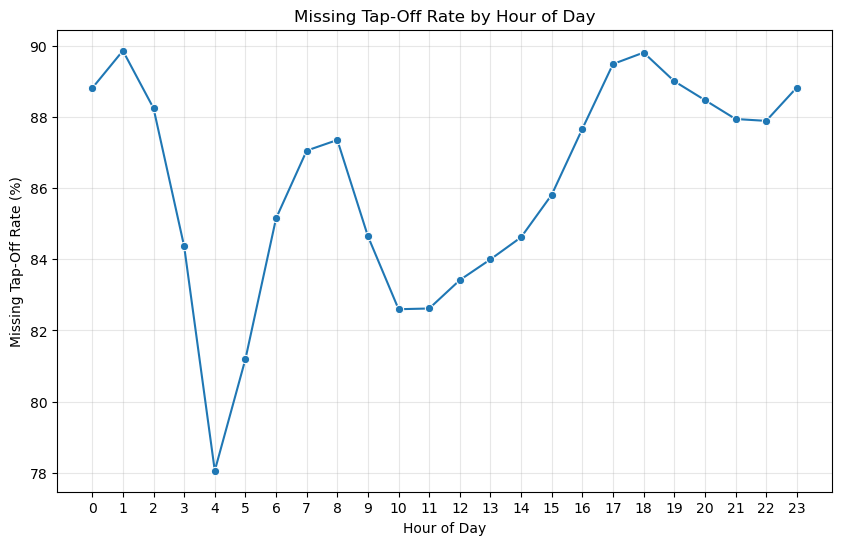

In [24]:
trips["hour"] = trips["date_time_on"].dt.hour

hourly_missing = (
    trips.groupby("hour")
    .agg(
        total=("card_id","count"),
        missing=("stop_id_off", lambda x: x.isna().sum())
    )
)

hourly_missing["missing_rate"] = (
    hourly_missing["missing"] /
    hourly_missing["total"] * 100
)


plt.figure(figsize=(10,6))
sns.lineplot(
    data=hourly_missing,
    x=hourly_missing.index,
    y="missing_rate",
    marker="o"
)

plt.title("Missing Tap-Off Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Missing Tap-Off Rate (%)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

#### Finding 2 -  Stop Efficiency Analysis

In [25]:
# Tap-on count
on_counts = trips["StopNumber_on"].value_counts()

# Tap-off count
off_counts = trips["StopNumber_off"].value_counts()

# Combine
stop_efficiency = pd.concat(
    [on_counts, off_counts],
    axis=1
).fillna(0)

stop_efficiency.columns = [
    "tap_on",
    "tap_off"
]

stop_efficiency["off_on_ratio"] = (
    stop_efficiency["tap_off"] /
    stop_efficiency["tap_on"]
)

stop_info = (
    trips[
        [
            "StopNumber_on",
            "StopName_on",
            "parent_route"
        ]
    ]
    .drop_duplicates()
)

stop_efficiency = (
    stop_efficiency
    .reset_index()
    .rename(columns={"index": "StopNumber_on"})
    .merge(
        stop_info,
        on="StopNumber_on",
        how="left"
    )
)

In [51]:
destination_stops = (
    stop_efficiency
    .sort_values(
        "off_on_ratio",
        ascending=False
    )
    .head(20)
)

In [53]:
origin_stops = (
    stop_efficiency
    .sort_values(
        "off_on_ratio"
    )
    .head(20)
)

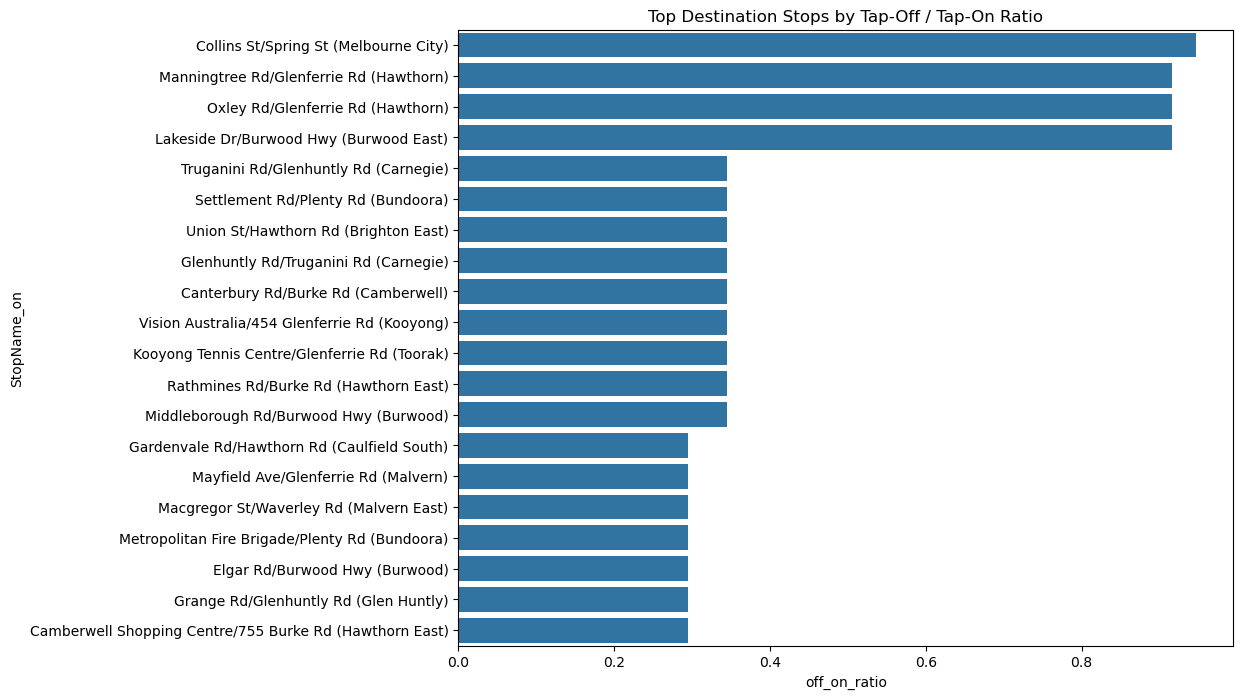

In [91]:
top_destinations = destination_stops.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_destinations,
    x="off_on_ratio",
    y="StopName_on"
)

plt.title(
    "Top Destination Stops by Tap-Off / Tap-On Ratio"
)

plt.show()

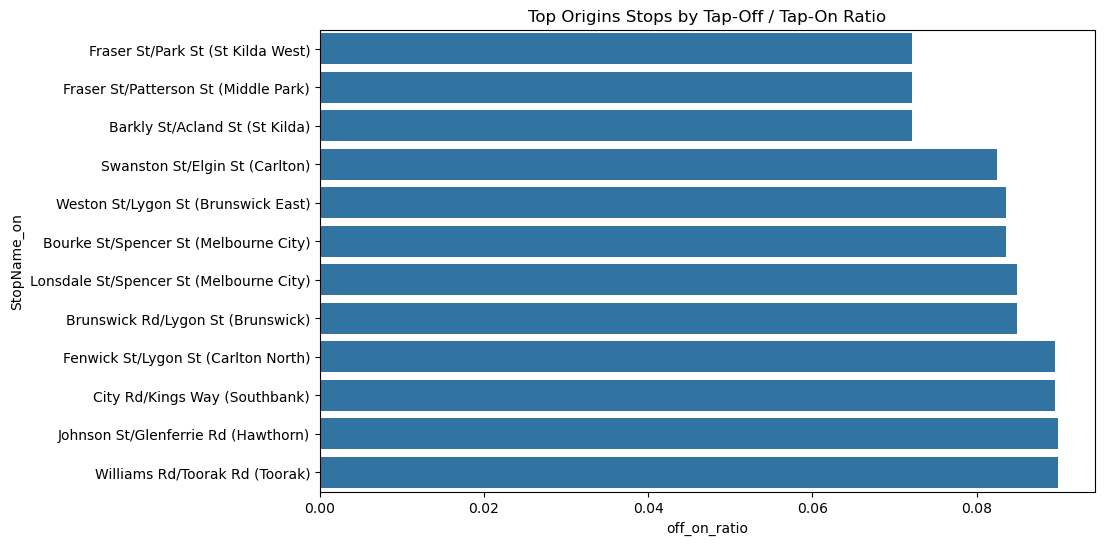

In [93]:
top_origins = origin_stops.head(20)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_origins,
    x="off_on_ratio",
    y="StopName_on"
)

plt.title(
    "Top Origins Stops by Tap-Off / Tap-On Ratio"
)

plt.show()

#### Finding 3 - Busiest routes

In [98]:
trips["date"] = pd.to_datetime(trips["date_time_on"]).dt.date
# Count passengers per route per day
daily_route_counts = (
    trips.groupby(["parent_route", "date"])
    .size()
    .reset_index(name="passenger_count")
)

# Compute yearly average per route
avg_route_counts = (
    daily_route_counts.groupby("parent_route")["passenger_count"]
    .mean()
    .reset_index(name="avg_daily_passengers")
)

# Get top 10 routes

top10_routes = avg_route_counts.sort_values(
    by="avg_daily_passengers",
    ascending=False
).head(10)

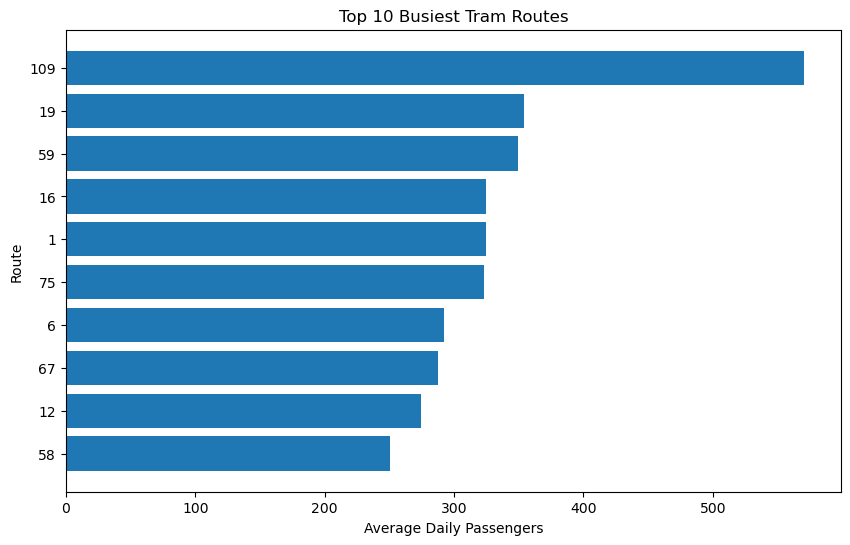

In [100]:
# Visualization
plt.figure(figsize=(10, 6))

plt.barh(
    top10_routes["parent_route"].astype(str),
    top10_routes["avg_daily_passengers"]
)

plt.xlabel("Average Daily Passengers")
plt.ylabel("Route")
plt.title("Top 10 Busiest Tram Routes")

plt.gca().invert_yaxis()
plt.show()

#### Finding 4 - Longest routes

In [102]:
trips["travel_time"] = (
    trips["date_time_off"] - trips["date_time_on"]
)

# Remove invalid trips

valid_trips = trips[
    trips["travel_time"].notna() &
    (trips["travel_time"] > pd.Timedelta("0 minutes")) &
    (trips["travel_time"] < pd.Timedelta("3 hours"))
].copy()

# Convert to minutes

valid_trips["travel_time_min"] = (
    valid_trips["travel_time"].dt.total_seconds() / 60
)

# Average travel time per route

avg_travel_time = (
    valid_trips.groupby("parent_route")["travel_time_min"]
    .mean()
    .reset_index(name="avg_travel_time_min")
)

# Get top 10 longest routes

top10_longest = avg_travel_time.sort_values(
    by="avg_travel_time_min",
    ascending=False
).head(10)

    parent_route  avg_travel_time_min
16            75            45.967401
17            86            44.887976
19           109            44.289370
7             48            43.488317
9             57            43.328922
5             16            43.283867
14            70            43.213593
6             19            43.133323
4             12            42.651832
10            58            42.375961


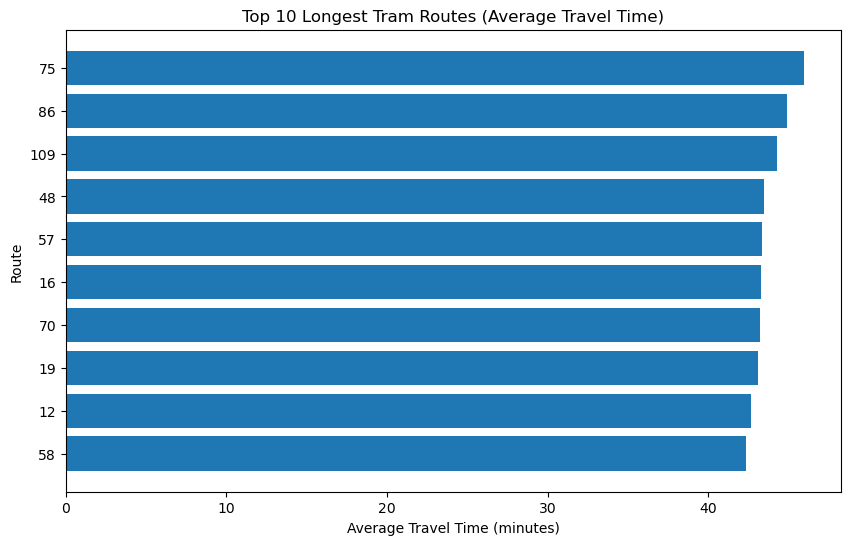

In [104]:
# Visualization 
plt.figure(figsize=(10, 6))

plt.barh(
    top10_longest["parent_route"].astype(str),
    top10_longest["avg_travel_time_min"]
)

plt.xlabel("Average Travel Time (minutes)")
plt.ylabel("Route")
plt.title("Top 10 Longest Tram Routes (Average Travel Time)")

plt.gca().invert_yaxis()
plt.show()

### Finding 5 - Routes Demand

In [106]:
# Extract hour + date
trips["hour"] = pd.to_datetime(trips["date_time_on"]).dt.hour
trips["day_of_week"] = pd.to_datetime(trips["date_time_on"]).dt.date
trips["is_weekend"] = (
    trips["date_time_on"].dt.dayofweek >= 5
)

# Defining peak hours
peak_hours = [7, 8, 9, 16, 17, 18]

trips["peak_period"] = np.where(
    trips["hour"].isin(peak_hours),
    "Peak",
    "Off-Peak"
)
# Compare total demand
peak_summary = (
    trips.groupby("peak_period")
    .size()
    .reset_index(name="trip_count")
)

peak_summary


,peak_period,trip_count
0,Off-Peak,1011449
1,Peak,893272


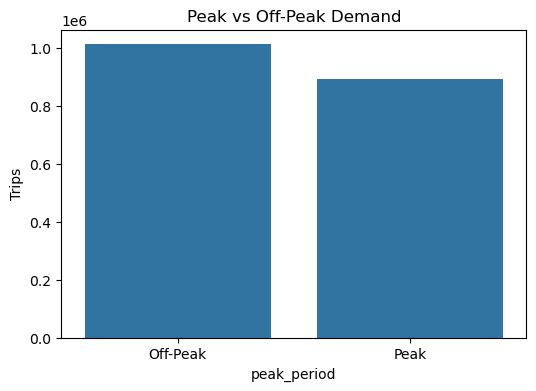

In [108]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=peak_summary,
    x="peak_period",
    y="trip_count"
)

plt.title("Peak vs Off-Peak Demand")
plt.ylabel("Trips")
plt.show()

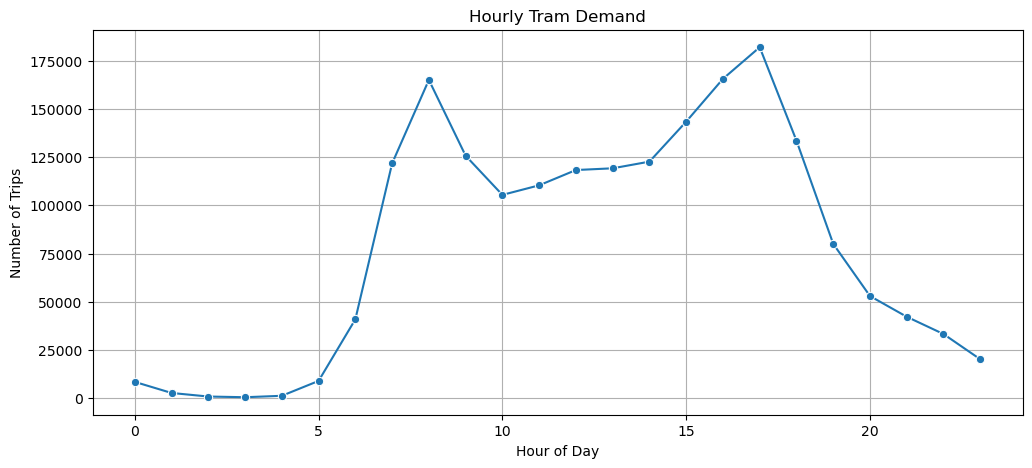

In [110]:
hourly_demand = (
    trips.groupby("hour")
    .size()
    .reset_index(name="trip_count")
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_demand,
    x="hour",
    y="trip_count",
    marker="o"
)

plt.title("Hourly Tram Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True)

plt.show()

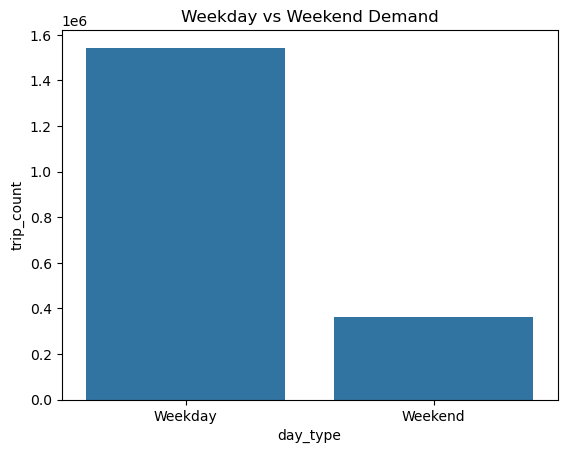

In [112]:
weekday_weekend = (
    trips.groupby("is_weekend")
    .size()
    .reset_index(name="trip_count")
)

weekday_weekend["day_type"] = (
    weekday_weekend["is_weekend"]
    .map({
        False: "Weekday",
        True: "Weekend"
    })
)

sns.barplot(
    data=weekday_weekend,
    x="day_type",
    y="trip_count"
)

plt.title("Weekday vs Weekend Demand")
plt.show()

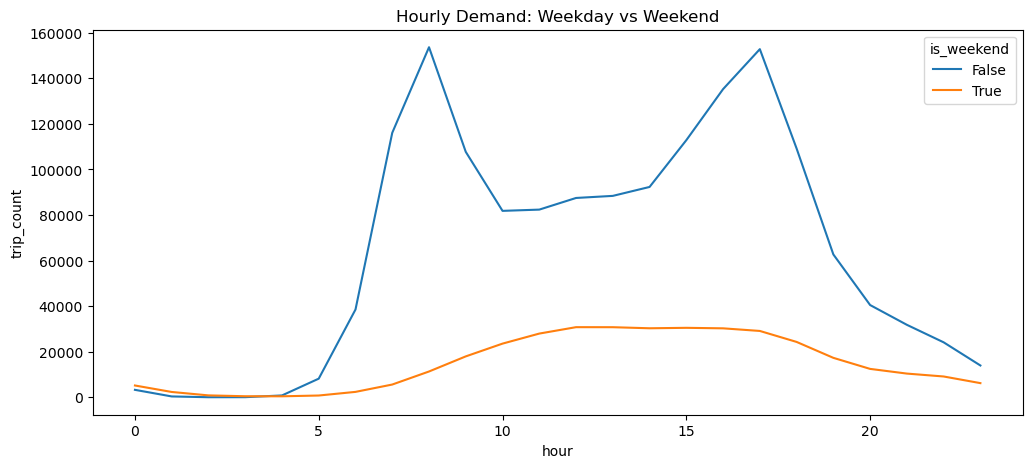

In [114]:
hour_day = (
    trips.groupby(
        ["hour", "is_weekend"]
    )
    .size()
    .reset_index(name="trip_count")
)
plt.figure(figsize=(12,5))

sns.lineplot(
    data=hour_day,
    x="hour",
    y="trip_count",
    hue="is_weekend"
)

plt.title(
    "Hourly Demand: Weekday vs Weekend"
)

plt.show()

In [116]:
route_peak = (
    trips.groupby(
        ["parent_route", "peak_period"]
    )
    .size()
    .reset_index(name="trip_count")
)
route_peak = (
    route_peak
    .pivot(
        index="parent_route",
        columns="peak_period",
        values="trip_count"
    )
    .fillna(0)
)

route_peak["peak_ratio"] = (
    route_peak["Peak"] /
    (route_peak["Peak"] + route_peak["Off-Peak"])
)

In [118]:
route_peak.sort_values(
    "peak_ratio",
    ascending=False
).head(10)

peak_period,Off-Peak,Peak,peak_ratio
parent_route,,,
5,26015,28483,0.522643
58,29159,31754,0.521301
55,21533,22986,0.516319
59,64502,63451,0.495893
96,45033,43555,0.491658
6,55384,53184,0.489868
109,107886,97485,0.474678
48,44456,39944,0.473270
1,63847,56652,0.470145


### Phase 3 - Insights and Recommendations.

#### Insights

1. Boarding demand is a more reliable performance indicator than passenger journeys in Melbourne's tram network.
2. Certain stops function as major passenger hubs and require priority resource allocation.
3. Passenger demand is heavily concentrated on a small number of routes.
4. Long-duration routes present the greatest risk of service delays.
5. Demand patterns support dynamic service scheduling.


#### Recommendations

1. Prioritise service capacity at major boarding hubs:
High-demand stops such as Melbourne Central, Flinders Street, Federation Square, and Melbourne University consistently attract the largest passenger volumes. PTV should increase tram frequency during peak periods and prioritise infrastructure upgrades at these locations to reduce overcrowding and improve passenger flow.

2. Implement demand-based scheduling across routes and time periods:
Passenger demand is unevenly distributed across routes and varies significantly between peak and off-peak hours. Using historical tap-on patterns to dynamically allocate trams and adjust service frequency can improve resource utilisation, reduce waiting times, and lower operating inefficiencies.

3. Improve connectivity and accessibility around key destination stops:
Stops with high tap-off-to-tap-on ratios appear to function as major passenger destinations rather than boarding points. Enhancing pedestrian access, wayfinding signage, interchange connections, and local transport integration around these destinations can improve the overall passenger experience and network accessibility.